# **FASE 3.2 – Agrupamento de Dados: Análises Diversas**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [21]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes

### **Realizando a leitura da base de área de MG**

In [2]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Codificação das variáveis**
Nesse caso, será realizado a transformação da variável **TP_SEXO**, convertendo o valor 'M' para 0 e o valor 'F' para 1.

In [3]:
df_final["TP_SEXO"] = df_final["TP_SEXO"].map({"F": 1, "M": 0})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, a variável **TP_ESTADO_CIVIL** foi recodificada para valores numéricos, de forma que Solteiro(a) foi representado por 0, Casado(a)/Companheiro(a) por 1, e as demais categorias (Divorciado(a), Desquitado(a), Separado(a) e Viúvo(a)) foram agrupadas sob o valor 2, representando o grupo “Outros”

In [4]:
df_final["TP_ESTADO_CIVIL"] = df_final["TP_ESTADO_CIVIL"].replace({
    "Solteiro(a)": 0,
    "Casado(a)/Companheiro(a)": 1,
    "Divorciado(a)/Separado(a)": 2,
    "Desquitado(a)": 2,
    "Viúvo(a)": 2
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, aplicou-se o método one-hot encoding à variável **TP_COR_RACA**, criando colunas binárias (0 e 1) para cada categoria de cor/raça. Essa transformação permite representar variáveis categóricas de forma numérica, sem atribuir uma ordem entre as categorias.

In [5]:
df_final = pd.get_dummies(df_final, columns=["TP_COR_RACA"], prefix="COR_RACA")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,1,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,1,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,1,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,1,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,1,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,3,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,1,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,1,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,1,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_NACIONALIDADE**, transformando as categorias originais em valores numéricos binários:

0 → Brasileiro(a), Brasileiro(a) Naturalizado(a) ou Brasileiro(a) Nato(a), nascido(a) no exterior

1 → Estrangeiro(a)

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [6]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_NACIONALIDADE"] != 0].copy()

df_final.loc[:, "TP_NACIONALIDADE"] = df_final["TP_NACIONALIDADE"].replace({
    1: 0,  # Brasileiro(a)
    2: 0,  # Brasileiro(a) Naturalizado(a)
    4: 0,  # Brasileiro(a) Nato(a), nascido(a) no exterior
    3: 1   # Estrangeiro(a)
})

depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517827
Total de linhas após a exclusão: 517522
Foram removidas 305 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_NACIONALIDADE**, o conjunto de dados passou de 517827 para 517522 registros, resultando na exclusão de 305 observações com nacionalidade “Não informada”.

Nesta etapa, será realizada a recodificação da variável **TP_ENSINO**, transformando as categorias originais em valores numéricos binários:

0 → Educação Especial – Modalidade Substitutiva e Educação de Jovens e Adultos

1 → Ensino Regular

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [7]:
df_final.loc[:, "TP_ENSINO"] = df_final["TP_ENSINO"].replace({
    2: 0,  # Educação Especial – Modalidade Substitutiva
    3: 0  # Educação de Jovens e Adultos
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_ESCOLA**, transformando as categorias originais em valores numéricos binários:

0 → Pública

1 → Exterior e Privada

As observações com valor 1 (Não respondeu) serão removidas do conjunto de dados.

In [8]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_ESCOLA"] != 1].copy()

df_final.loc[:, "TP_ESCOLA"] = df_final["TP_ESCOLA"].replace({
    2: 0,  # Pública
    3: 1,  # Exterior
    4: 1   # Privada
})
depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517522
Total de linhas após a exclusão: 511774
Foram removidas 5748 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_ESCOLA**, o conjunto de dados passou de 517522 para 511774 registros, resultando na exclusão de 5748 observações com nacionalidade “Não respondeu”.

Nesta etapa, será realizada a recodificação da variável **ESQ_PAI, ESC_MAE, OCU_PAI, OCU_MAE, RENDA_MENSAL, EMP_DOMESTICO, BANHEIRO, QTD_QUARTOS, CARRO, MOTO, GELADEIRA, FREEZER, LAVA_ROUPA, SECA_ROUPA, MICROONDAS, LAVA_LOUCA, ASPIRADOR, TV, DVD, TV_ASSINATURA, CELULAR, TELEFONE_FIXO, COMPUTADOR, INTERNET**, transformando as categorias originais em valores numéricos binários

In [9]:
colunas_categoricas = [
    'ESQ_PAI', 'ESC_MAE', 'OCU_PAI', 'OCU_MAE', 'RENDA_MENSAL',
    'EMP_DOMESTICO', 'BANHEIRO', 'QTD_QUARTOS', 'CARRO', 'MOTO',
    'GELADEIRA', 'FREEZER', 'LAVA_ROUPA', 'SECA_ROUPA', 'MICROONDAS',
    'LAVA_LOUCA', 'ASPIRADOR', 'TV', 'DVD', 'TV_ASSINATURA',
    'CELULAR', 'TELEFONE_FIXO', 'COMPUTADOR', 'INTERNET'
]
mapa = {chr(i + 65): i for i in range(26)}  # 'A'->0, 'B'->1, ..., 'Z'->25

for col in colunas_categoricas:
    df_final[col] = df_final[col].map(mapa)

df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,1.0,1.0,1.0,1.0,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,1.0,0.0,0.0,0.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,2.0,0.0,0.0,1.0,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,4.0,0.0,3.0,1.0,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,3.0,0.0,1.0,1.0,False,False,False,True,False,False


### **Filtrando a área de abrangencia do IFNMG**

In [10]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
6,2018,2,0,0.0,0,2,0,1.0,Chapada do Norte,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
9,2018,3,1,0.0,0,2,0,1.0,Teófilo Otoni,MG,...,4.0,0.0,1.0,1.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,0.0,2.0,1.0,False,False,False,True,False,False
517781,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,1.0,0.0,0.0,1.0,False,False,False,True,False,False
517789,2023,4,0,1.0,0,2,0,NaN,Teófilo Otoni,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517799,2023,2,0,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,1.0,2.0,1.0,False,False,False,True,False,False


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **K-modes de algumas variáveis [sexo, faixa etaria, tipo de escola e escolaridade e renda]**

Colunas encontradas no df_ifnmg: ['TP_SEXO', 'TP_FAIXA_ETARIA', 'TP_ESCOLA', 'TP_ENSINO', 'RENDA_MENSAL']

Formato da base para KModes: (69594, 5)
Primeiras linhas:
   TP_SEXO  TP_FAIXA_ETARIA  TP_ESCOLA  TP_ENSINO  RENDA_MENSAL
0        0                3          0        1.0           1.0
1        1                2          0        1.0           3.0
4        0                2          0        1.0           2.0
6        0                2          0        1.0           0.0
9        1                3          0        1.0           7.0
k=2 → custo=88422 | silhouette=0.3357
k=3 → custo=71254 | silhouette=0.3091
k=4 → custo=61031 | silhouette=0.3663
k=5 → custo=55424 | silhouette=0.2603
k=6 → custo=55634 | silhouette=0.3349
k=7 → custo=50389 | silhouette=0.2100
k=8 → custo=46891 | silhouette=0.2800
k=9 → custo=45380 | silhouette=0.3061


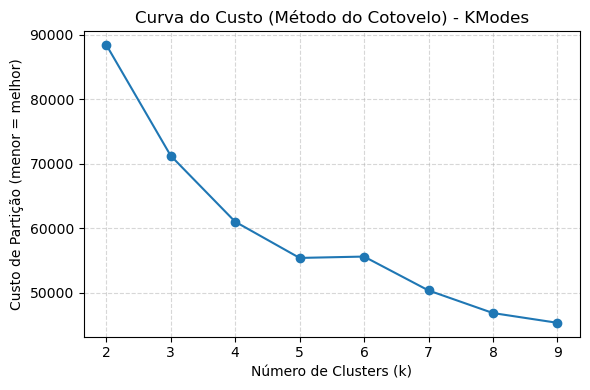

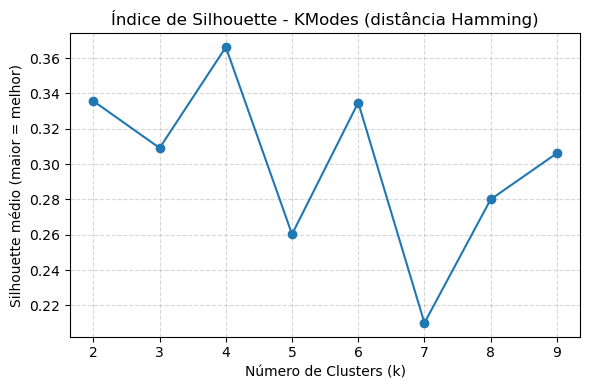


➡ Melhor k pelo menor custo: 9
➡ Melhor k pelo maior silhouette: 4

Quantidade de observações por cluster (k=4):
Cluster_KModes
0    27808
1    13666
2    10166
3    17954
Name: count, dtype: int64

Modos (centroides) de cada cluster:
  TP_SEXO TP_FAIXA_ETARIA TP_ESCOLA TP_ENSINO RENDA_MENSAL  Cluster_KModes
0       1               3         0       1.0          1.0               0
1       0               2         0       1.0          1.0               1
2       0               3         0       1.0          2.0               2
3       1               2         0       1.0          1.0               3

% de sexo dentro de cada cluster:
TP_SEXO             0      1
Cluster_KModes              
0                14.4   85.6
1               100.0    0.0
2               100.0    0.0
3                 0.0  100.0

% de tipo de escola dentro de cada cluster:
TP_ESCOLA          0     1
Cluster_KModes            
0               94.0   6.0
1               88.0  12.0
2               87.4  12.6


In [11]:
colunas_desejadas = ["TP_SEXO", "TP_FAIXA_ETARIA", "TP_ESCOLA", "TP_ENSINO", "RENDA_MENSAL"]

presentes = [c for c in colunas_desejadas if c in df_ifnmg.columns]
faltando = [c for c in colunas_desejadas if c not in df_ifnmg.columns]

print("Colunas encontradas no df_ifnmg:", presentes)
if faltando:
    print("⚠️ Atenção, essas colunas NÃO foram encontradas no df_ifnmg:", faltando)

# Base categórica sem NA
base_cat = df_ifnmg[presentes].dropna().copy()

print("\nFormato da base para KModes:", base_cat.shape)
print("Primeiras linhas:")
print(base_cat.head())

X_kmodes = base_cat.astype(str).to_numpy()

base_cat_codes = base_cat.copy()
for c in base_cat_codes.columns:
    base_cat_codes[c] = base_cat_codes[c].astype("category").cat.codes
X_sil = base_cat_codes.to_numpy()

custos = []
silhuetas = []
Ks = range(2, 10)

for k in Ks:
    km = KModes(n_clusters=k, init="Huang", n_init=10, random_state=42)
    labels = km.fit_predict(X_kmodes)

    custo = km.cost_
    custos.append(custo)

    sil = silhouette_score(X_sil, labels, metric="hamming")
    silhuetas.append(sil)

    print(f"k={k} → custo={custo:.0f} | silhouette={sil:.4f}")

# Plot do custo
plt.figure(figsize=(6, 4))
plt.plot(Ks, custos, marker="o")
plt.title("Curva do Custo (Método do Cotovelo) - KModes")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Custo de Partição (menor = melhor)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Plot do silhouette
plt.figure(figsize=(6, 4))
plt.plot(Ks, silhuetas, marker="o")
plt.title("Índice de Silhouette - KModes (distância Hamming)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette médio (maior = melhor)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

melhor_k_custo = Ks[np.argmin(custos)]
melhor_k_sil = Ks[np.argmax(silhuetas)]

print(f"\n➡ Melhor k pelo menor custo: {melhor_k_custo}")
print(f"➡ Melhor k pelo maior silhouette: {melhor_k_sil}")

k_escolhido = 4  

kmodes_final = KModes(n_clusters=k_escolhido, init="Huang", n_init=10, random_state=42)
labels_final = kmodes_final.fit_predict(X_kmodes)

base_cat = base_cat.copy()
base_cat["Cluster_KModes"] = labels_final

print(f"\nQuantidade de observações por cluster (k={k_escolhido}):")
print(base_cat["Cluster_KModes"].value_counts().sort_index())

centroides = pd.DataFrame(kmodes_final.cluster_centroids_, columns=base_cat.columns[:-1])
centroides["Cluster_KModes"] = centroides.index
print("\nModos (centroides) de cada cluster:")
print(centroides)

df_ifnmg = df_ifnmg.copy()
df_ifnmg.loc[base_cat.index, "Cluster_KModes"] = base_cat["Cluster_KModes"].values

if "TP_SEXO" in presentes:
    print("\n% de sexo dentro de cada cluster:")
    print(
        (pd.crosstab(base_cat["Cluster_KModes"], base_cat["TP_SEXO"], normalize="index") * 100).round(1)
    )

if "TP_ESCOLA" in presentes:
    print("\n% de tipo de escola dentro de cada cluster:")
    print(
        (pd.crosstab(base_cat["Cluster_KModes"], base_cat["TP_ESCOLA"], normalize="index") * 100).round(1)
    )

print(f"\nA coluna 'Cluster_KModes' (k={k_escolhido}) foi adicionada ao df_ifnmg com sucesso!")
df_final["Cluster_KModes"] = df_ifnmg["Cluster_KModes"]

## **Análise dos Clusters**

## **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**


Contagem por ano e cluster:
   NU_ANO Cluster_Nome  Quantidade
0    2018     Perfil A        8513
1    2018     Perfil B        3780
2    2018     Perfil C        2758
3    2018     Perfil D        5044
4    2019     Perfil A        6194


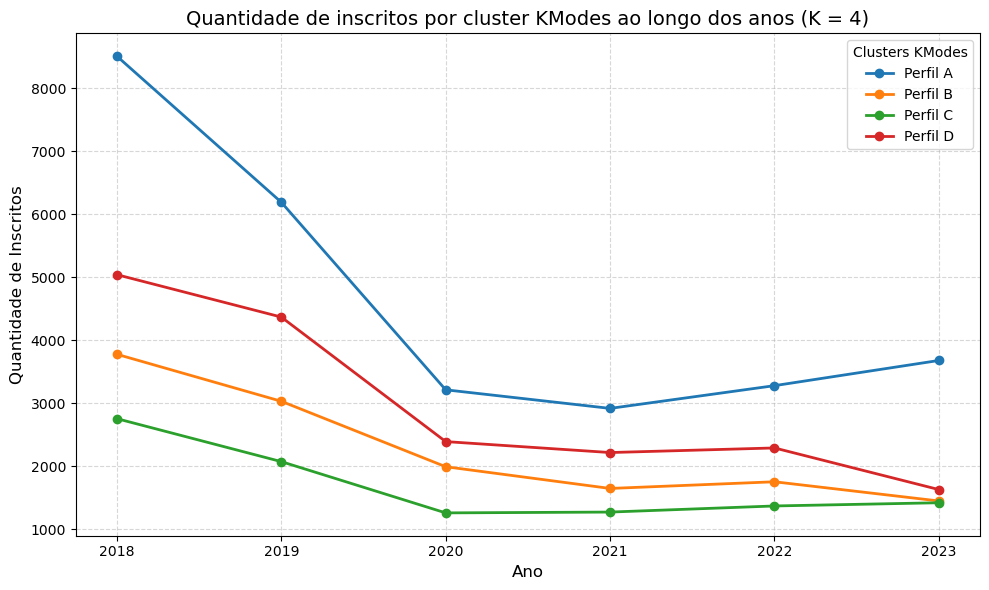


Porcentagem de cada cluster por ano (%):
Cluster_Nome  Perfil A  Perfil B  Perfil C  Perfil D
NU_ANO                                              
2018              42.4      18.8      13.7      25.1
2019              39.5      19.4      13.2      27.9
2020              36.3      22.5      14.2      27.0
2021              36.2      20.5      15.8      27.5
2022              37.7      20.2      15.8      26.3
2023              45.0      17.7      17.4      19.9


In [12]:
# ============================================================
# 1️⃣ Dicionário de nomes dos clusters (K = 4)
# ============================================================
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D"
}


# ============================================================
# 2️⃣ Mapeamento dos nomes no DataFrame
# ============================================================
df_ifnmg["Cluster_Nome"] = df_ifnmg["Cluster_KModes"].map(nomes_clusters)


# ============================================================
# 3️⃣ Verificação de colunas obrigatórias
# ============================================================
colunas_necessarias = ["NU_ANO", "Cluster_KModes", "Cluster_Nome"]

for col in colunas_necessarias:
    if col not in df_ifnmg.columns:
        raise ValueError(f"A coluna {col} não existe no df_ifnmg!")


# ============================================================
# 4️⃣ Contagem por ano e cluster
# ============================================================
contagem_kmodes = (
    df_ifnmg
    .groupby(["NU_ANO", "Cluster_Nome"])
    .size()
    .reset_index(name="Quantidade")
)

print("\nContagem por ano e cluster:")
print(contagem_kmodes.head())


# ============================================================
# 5️⃣ Gráfico — Evolução ao longo dos anos
# ============================================================
plt.figure(figsize=(10, 6))

clusters_unicos = contagem_kmodes["Cluster_Nome"].unique()

for nome in clusters_unicos:
    df_plot = contagem_kmodes[contagem_kmodes["Cluster_Nome"] == nome]
    plt.plot(
        df_plot["NU_ANO"],
        df_plot["Quantidade"],
        marker="o",
        linewidth=2,
        label=nome
    )

plt.title(
    "Quantidade de inscritos por cluster KModes ao longo dos anos (K = 4)",
    fontsize=14
)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Inscritos", fontsize=12)
plt.legend(title="Clusters KModes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(sorted(df_ifnmg["NU_ANO"].unique()))
plt.tight_layout()
plt.show()


# ============================================================
# 6️⃣ Tabela percentual por ano
# ============================================================
tabela_pct = (
    contagem_kmodes
    .pivot(index="NU_ANO", columns="Cluster_Nome", values="Quantidade")
    .apply(lambda x: (x / x.sum() * 100).round(1), axis=1)
)

print("\nPorcentagem de cada cluster por ano (%):")
print(tabela_pct)

## **Quantidade de inscritos por grupo para cada tipo de escola**

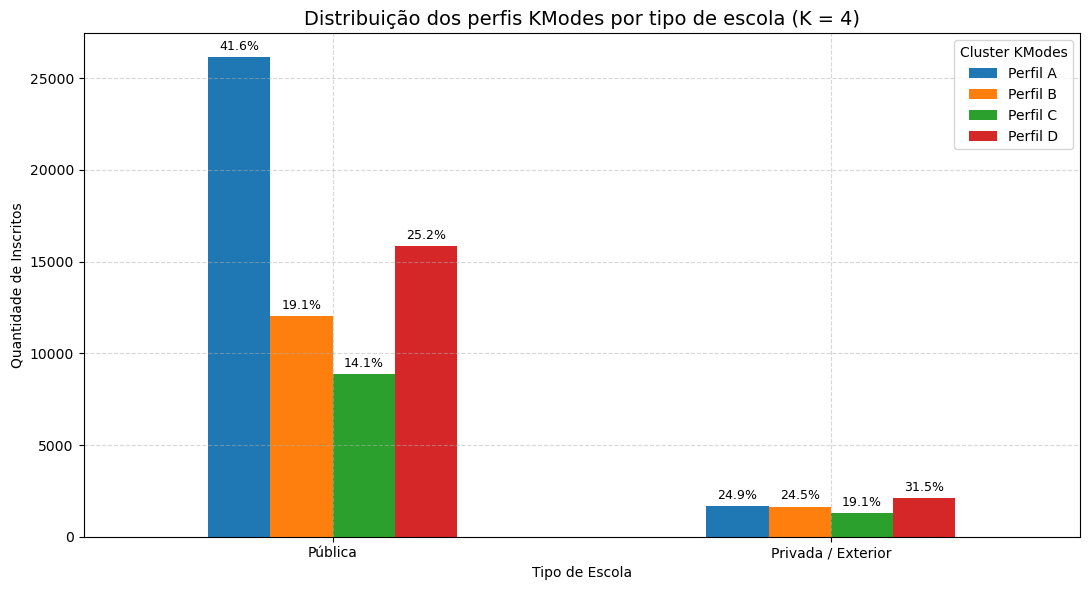


Resumo total por cluster KModes (K = 4):
          Quantidade  Porcentagem
Cluster                          
Perfil A       27808         40.0
Perfil B       13666         19.6
Perfil C       10166         14.6
Perfil D       17954         25.8


In [13]:
# ============================================================
# 1️⃣ Nomes dos clusters (K = 4)
# ============================================================
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D"
}


# ============================================================
# 2️⃣ Preparação da base
# ============================================================
df_k = df_ifnmg.copy()
df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)

cols = ["TP_ESCOLA", "Cluster"]
base = df_k[cols].dropna().copy()


# ============================================================
# 3️⃣ Mapeamento e ordenação do tipo de escola
# ============================================================
mapa_escola = {
    0: "Pública",
    1: "Privada / Exterior"
}

ordem_escola = [0, 1]

base["TP_ESCOLA"] = pd.Categorical(
    base["TP_ESCOLA"],
    categories=ordem_escola,
    ordered=True
)


# ============================================================
# 4️⃣ Contagem por tipo de escola e cluster
# ============================================================
contagem = (
    base
    .groupby(["TP_ESCOLA", "Cluster"], observed=True)
    .size()
    .rename("Quantidade")
    .reset_index()
)


# ============================================================
# 5️⃣ Tabela cruzada
# ============================================================
tabela = (
    contagem
    .pivot_table(
        index="TP_ESCOLA",
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(
        index=ordem_escola,
        columns=list(nomes_clusters.values())
    )
    .fillna(0)
    .astype(int)
)

tabela.index = [mapa_escola[i] for i in tabela.index]


# ============================================================
# 6️⃣ Percentuais por tipo de escola
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 7️⃣ Gráfico
# ============================================================
ax = tabela.plot(kind="bar", figsize=(11, 6))

ax.set_title(
    "Distribuição dos perfis KModes por tipo de escola (K = 4)",
    fontsize=14
)
ax.set_xlabel("Tipo de Escola")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Cluster KModes")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 8️⃣ Resumo total por cluster
# ============================================================
tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes (K = 4):")
print(tabela_total)


Observa-se que a maior concentração de candidatos é oriunda de escolas públicas, que representam a maioria absoluta dos inscritos em todos os clusters analisados. Nesse grupo, o Perfil A se destaca de forma expressiva, concentrando a maior parcela dos candidatos, seguido pelo Perfil D e pelo Perfil B. O Perfil C apresenta menor representatividade relativa entre os estudantes de escolas públicas, embora ainda componha uma fração relevante do total.

Entre os candidatos provenientes de escolas privadas ou do exterior, verifica-se uma redução significativa no volume absoluto de inscritos. No entanto, nesse segmento observa-se uma distribuição percentual mais equilibrada entre os perfis. O Perfil D passa a apresentar a maior participação relativa, seguido pelos Perfis A e B, enquanto o Perfil C mantém a menor proporção. Esse comportamento indica que, apesar do menor contingente total, os perfis entre candidatos de escolas privadas ou do exterior tendem a se distribuir de forma mais homogênea quando comparados aos de escolas públicas.

## **Quantidade de inscritos por grupo para cada gênero**

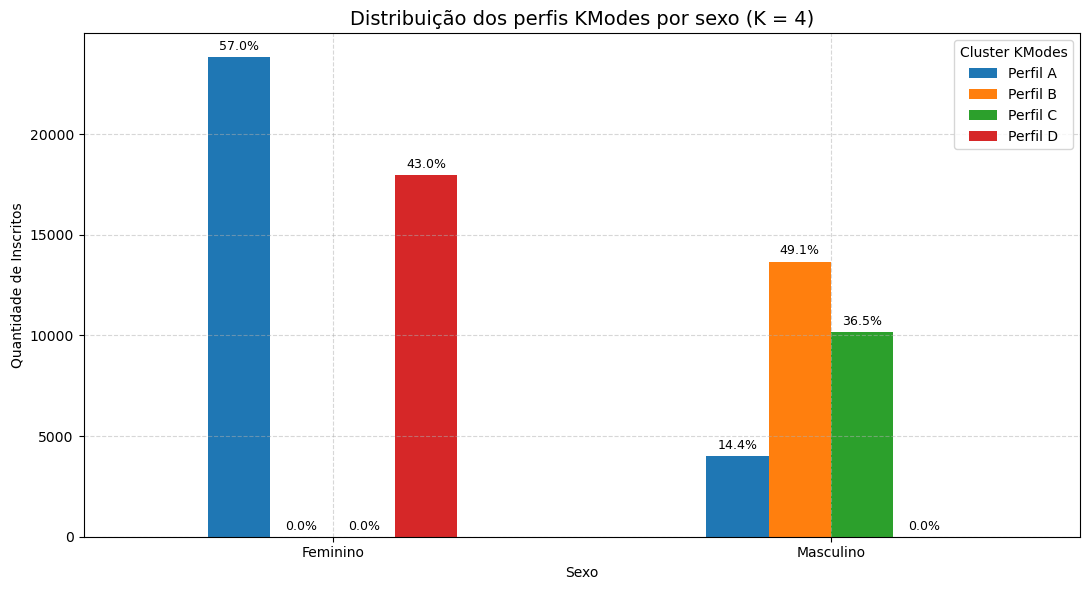


Resumo total por cluster KModes (K = 4):
          Quantidade  Porcentagem
Cluster                          
Perfil A       27808         40.0
Perfil B       13666         19.6
Perfil C       10166         14.6
Perfil D       17954         25.8


In [14]:
# ============================================================
# 1️⃣ Nomes dos clusters (K = 4)
# ============================================================
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D"
}


# ============================================================
# 2️⃣ Preparação da base
# ============================================================
df_k = df_ifnmg.copy()
df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)

cols = ["TP_SEXO", "Cluster"]
base = df_k[cols].dropna().copy()


# ============================================================
# 3️⃣ Mapeamento e ordenação do sexo
# ============================================================
mapa_sexo = {
    1: "Feminino",
    0: "Masculino"
}

ordem_sexo = [1, 0]

base["TP_SEXO"] = pd.Categorical(
    base["TP_SEXO"],
    categories=ordem_sexo,
    ordered=True
)


# ============================================================
# 4️⃣ Contagem por sexo e cluster
# ============================================================
contagem = (
    base
    .groupby(["TP_SEXO", "Cluster"], observed=True)
    .size()
    .rename("Quantidade")
    .reset_index()
)


# ============================================================
# 5️⃣ Tabela cruzada
# ============================================================
tabela = (
    contagem
    .pivot_table(
        index="TP_SEXO",
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(
        index=ordem_sexo,
        columns=list(nomes_clusters.values())
    )
    .fillna(0)
    .astype(int)
)

tabela.index = [mapa_sexo[i] for i in tabela.index]


# ============================================================
# 6️⃣ Percentuais por sexo
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 7️⃣ Gráfico
# ============================================================
ax = tabela.plot(kind="bar", figsize=(11, 6))

ax.set_title(
    "Distribuição dos perfis KModes por sexo (K = 4)",
    fontsize=14
)
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Cluster KModes")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 8️⃣ Resumo total por cluster
# ============================================================
tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes (K = 4):")
print(tabela_total)


Observa-se que, entre as candidatas do sexo feminino, há uma forte concentração em dois perfis específicos. O Perfil A destaca-se como o mais numeroso, concentrando a maior parte das inscritas, seguido pelo Perfil D. Por outro lado, os Perfis B e C apresentam participação praticamente inexistente nesse grupo, indicando que essas tipologias não são representativas entre as mulheres no conjunto analisado.

No caso dos candidatos do sexo masculino, o padrão observado é substancialmente distinto. O Perfil B apresenta a maior representatividade, seguido pelo Perfil C, enquanto o Perfil A aparece com participação menor em comparação aos demais. O Perfil D não apresenta presença relevante entre os homens, reforçando a diferenciação clara entre os perfis predominantes por sexo.

De maneira geral, os resultados evidenciam que a distribuição dos clusters varia de forma expressiva conforme o sexo, indicando que homens e mulheres tendem a se concentrar em perfis distintos dentro da segmentação realizada pelo algoritmo KModes. Essa diferenciação sugere a existência de padrões comportamentais ou estruturais específicos associados a cada grupo, os quais influenciam diretamente a composição dos clusters.

## **Quantidade de inscritos por grupo para cada cor/raça**

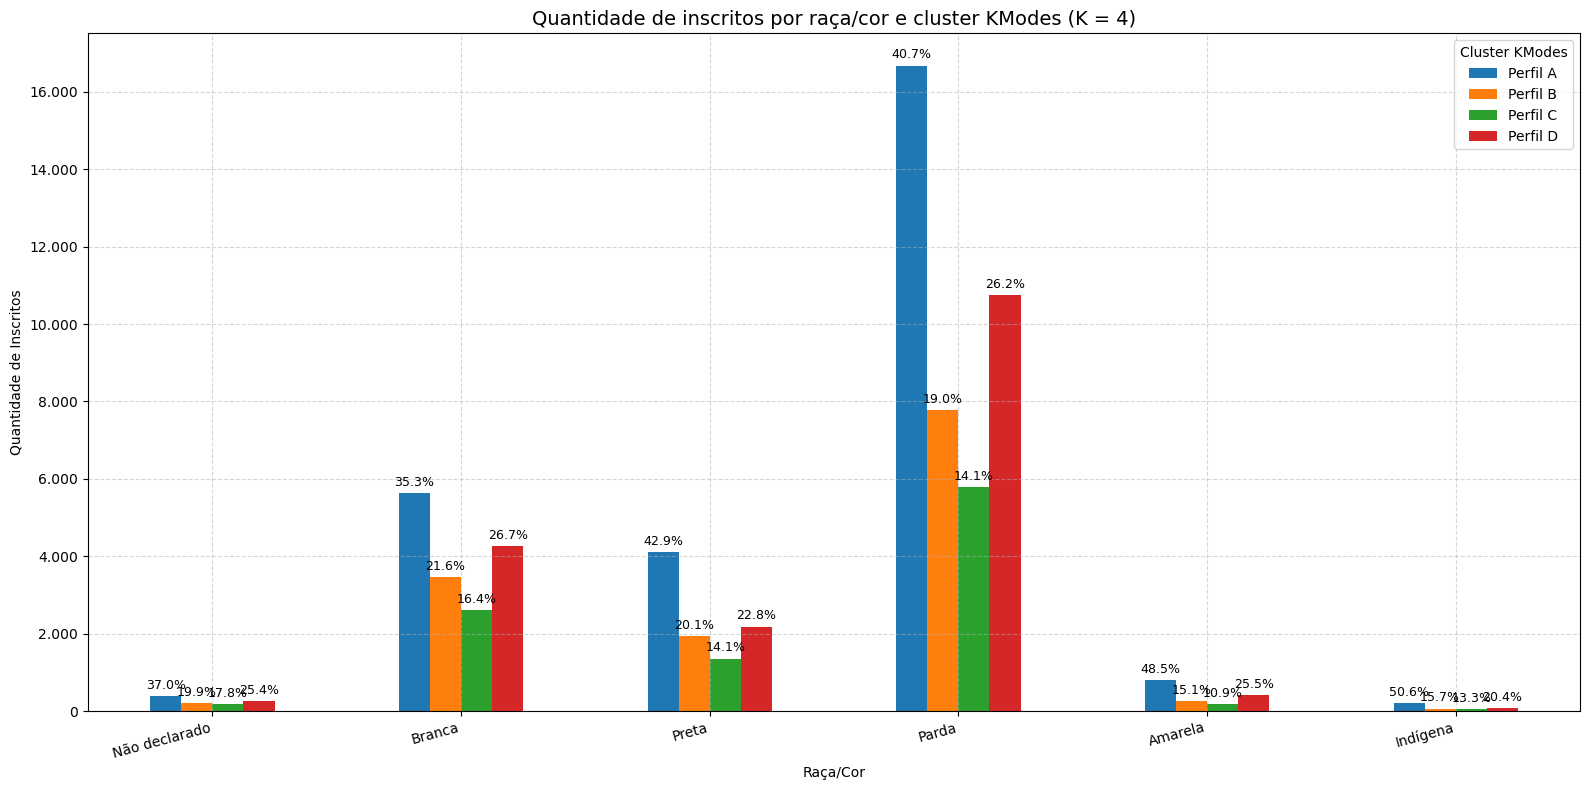


Resumo total por cluster KModes (K = 4):
          Quantidade  Porcentagem
Cluster                          
Perfil A       27808         40.0
Perfil B       13666         19.6
Perfil C       10166         14.6
Perfil D       17954         25.8


In [15]:
df_k = df_ifnmg.copy()

# ============================================================
# 1️⃣ Garantir coluna TP_COR_RACA
# ============================================================
if "TP_COR_RACA" not in df_k.columns:
    cols_raca = [c for c in df_k.columns if c.startswith("COR_RACA_")]
    if not cols_raca:
        raise ValueError("Não encontrei TP_COR_RACA nem colunas COR_RACA_*.")
    
    df_k["TP_COR_RACA"] = (
        df_k[cols_raca]
        .idxmax(axis=1)
        .str.replace("COR_RACA_", "")
        .astype(int)
    )


# ============================================================
# 2️⃣ Nomes dos clusters (K = 4)
# ============================================================
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D"
}

df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)


# ============================================================
# 3️⃣ Base de análise
# ============================================================
base = df_k[["TP_COR_RACA", "Cluster"]].dropna().copy()


# ============================================================
# 4️⃣ Mapeamento e ordenação de raça/cor
# ============================================================
ordem_raca = [0, 1, 2, 3, 4, 5]

mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}

base["TP_COR_RACA"] = pd.Categorical(
    base["TP_COR_RACA"],
    categories=ordem_raca,
    ordered=True
)


# ============================================================
# 5️⃣ Contagem por raça/cor e cluster
# ============================================================
contagem = (
    base
    .groupby(["TP_COR_RACA", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)


# ============================================================
# 6️⃣ Tabela cruzada
# ============================================================
tabela = (
    contagem
    .pivot(
        index="TP_COR_RACA",
        columns="Cluster",
        values="Quantidade"
    )
    .reindex(
        index=ordem_raca,
        columns=list(nomes_clusters.values())
    )
    .fillna(0)
    .astype(int)
)

tabela.index = [mapa_raca[i] for i in tabela.index]


# ============================================================
# 7️⃣ Percentuais por raça/cor
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 8️⃣ Gráfico
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))
tabela.plot(kind="bar", ax=ax)

ax.set_title(
    "Quantidade de inscritos por raça/cor e cluster KModes (K = 4)",
    fontsize=14
)
ax.set_xlabel("Raça/Cor")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=15, ha="right")

ax.legend(title="Cluster KModes")
ax.grid(True, linestyle="--", alpha=0.5)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 9️⃣ Resumo total por cluster
# ============================================================
tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes (K = 4):")
print(tabela_total)


Observa-se que o grupo Parda concentra a maior quantidade de inscritos em todos os perfis analisados, destacando-se como a principal categoria racial do conjunto de dados. Nesse grupo, o Perfil A apresenta a maior representatividade, seguido pelos Perfis D e B, enquanto o Perfil C aparece com menor participação relativa, ainda que expressiva em termos absolutos.

Em seguida, a categoria Branca também apresenta elevada representatividade, especialmente nos Perfis A e D, com participações relevantes dos Perfis B e C. Esse comportamento reforça a predominância desses dois grupos raciais na composição geral dos clusters identificados pelo algoritmo.

Na categoria Preta, observa-se novamente maior concentração no Perfil A, seguido pelos Perfis D e B, enquanto o Perfil C mantém participação mais reduzida. Apesar do menor volume absoluto quando comparado aos grupos Parda e Branca, a distribuição entre os perfis segue um padrão semelhante.

Já nas categorias de menor frequência — Amarela, Indígena e Não declarado — os números absolutos são significativamente mais baixos. Nesses grupos, a distribuição entre os perfis torna-se mais equilibrada, embora o Perfil A continue figurando entre os mais representativos, com diferenças menos acentuadas em relação aos demais perfis.

De forma geral, os resultados indicam que os perfis gerados pelo algoritmo KModes concentram-se majoritariamente entre candidatos que se autodeclaram pardos e brancos, refletindo a composição predominante da base analisada. Além disso, a presença consistente dos diferentes perfis dentro das principais categorias raciais sugere que, embora a raça/cor influencie a distribuição quantitativa dos inscritos, os clusters não se mostram rigidamente segmentados por esse atributo, indicando heterogeneidade interna dentro de cada perfil.

## **Quantidade de inscritos por grupo para cada faixa de renda mensal**

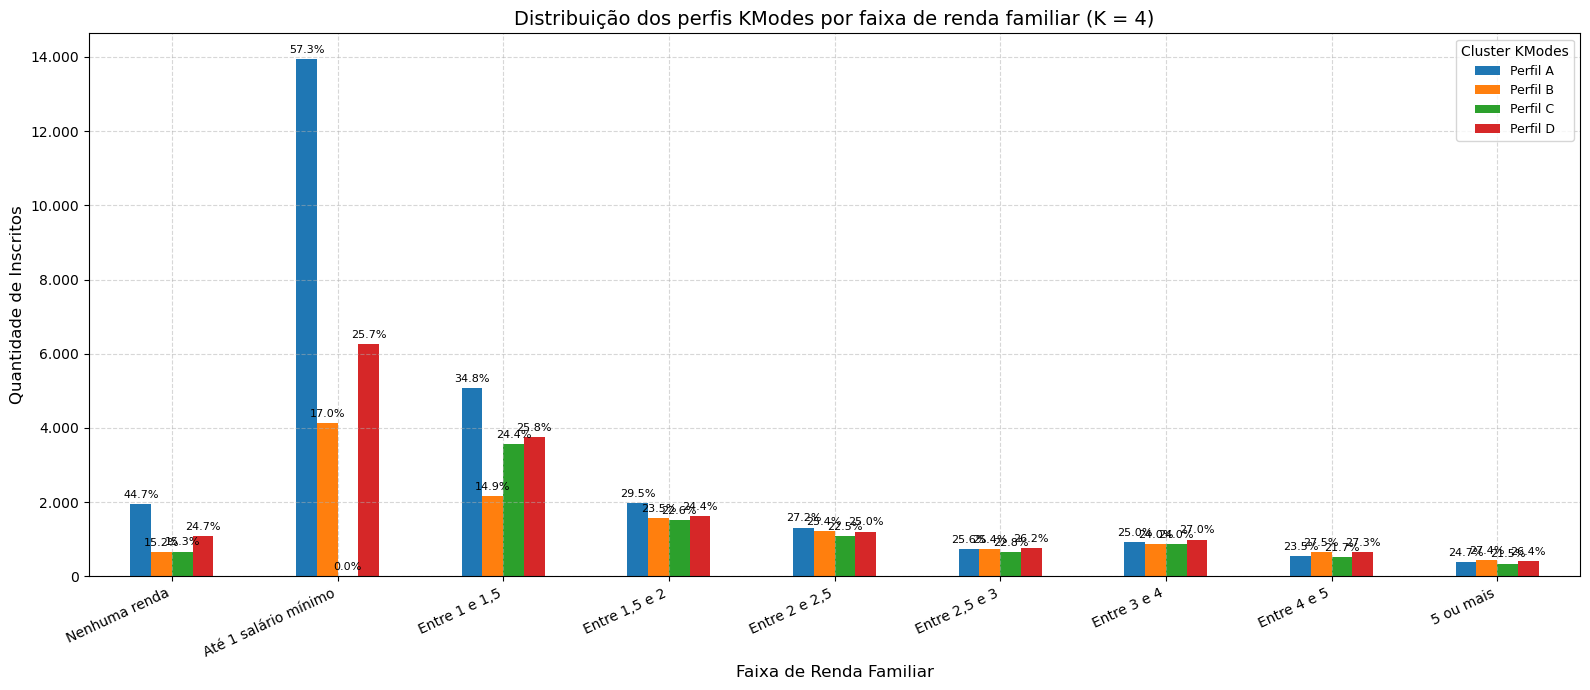


Resumo total por cluster KModes (K = 4):
          Quantidade  Porcentagem
Cluster                          
Perfil A       26860         41.1
Perfil B       12474         19.1
Perfil C        9223         14.1
Perfil D       16742         25.6


In [16]:
df_k = df_final.copy()

# ============================================================
# 1️⃣ Nomes dos clusters (K = 4)
# ============================================================
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D"
}

df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)


# ============================================================
# 2️⃣ Mapeamento da renda familiar
# ============================================================
mapa_renda_num = {
    0: "Nenhuma renda",
    1: "Até 1 salário mínimo",
    2: "Entre 1 e 1,5",
    3: "Entre 1,5 e 2",
    4: "Entre 2 e 2,5",
    5: "Entre 2,5 e 3",
    6: "Entre 3 e 4",
    7: "Entre 4 e 5",
    8: "5 ou mais"
}

df_k = df_k[df_k["RENDA_MENSAL"].isin(mapa_renda_num.keys())].copy()
df_k["Faixa_Renda"] = df_k["RENDA_MENSAL"].map(mapa_renda_num)


# ============================================================
# 3️⃣ Ordem das categorias
# ============================================================
ordem_renda = list(mapa_renda_num.values())
ordem_clusters = list(nomes_clusters.values())


# ============================================================
# 4️⃣ Contagem por faixa de renda e cluster
# ============================================================
contagem = (
    df_k
    .groupby(["Faixa_Renda", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)


# ============================================================
# 5️⃣ Tabela cruzada
# ============================================================
tabela = (
    contagem
    .pivot(
        index="Faixa_Renda",
        columns="Cluster",
        values="Quantidade"
    )
    .reindex(index=ordem_renda, columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 6️⃣ Percentuais por faixa de renda
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 7️⃣ Gráfico
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))
tabela.plot(kind="bar", ax=ax)

ax.set_title(
    "Distribuição dos perfis KModes por faixa de renda familiar (K = 4)",
    fontsize=14
)
ax.set_xlabel("Faixa de Renda Familiar", fontsize=12)
ax.set_ylabel("Quantidade de Inscritos", fontsize=12)
ax.set_xticklabels(tabela.index, rotation=25, ha="right")

ax.legend(title="Cluster KModes", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 8️⃣ Resumo total por cluster
# ============================================================
tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes (K = 4):")
print(tabela_total)


Observa-se inicialmente que, entre os candidatos sem renda familiar, há uma maior concentração no Perfil A, seguido pelo Perfil D e pelo Perfil B, enquanto o Perfil C apresenta participação menor. Esse padrão sugere que o Perfil A concentra, de forma mais expressiva, candidatos em situação de maior vulnerabilidade socioeconômica.

Na faixa de renda até 1 salário mínimo, verifica-se novamente forte predominância do Perfil A, que representa mais da metade dos inscritos nessa categoria. O Perfil D aparece em seguida com participação relevante, enquanto os Perfis B e C apresentam menor representatividade, indicando uma concentração mais acentuada em perfis específicos nas faixas de renda mais baixas.

Nas faixas intermediárias, especialmente entre 1 e 1,5 salários mínimos e entre 1,5 e 2 salários mínimos, observa-se uma distribuição mais equilibrada entre os perfis. Nessas categorias, o Perfil A continua apresentando maior participação, porém os Perfis B, C e D ganham representatividade, reduzindo a distância entre os grupos. Destaca-se, em particular, o crescimento relativo do Perfil C nessas faixas, sugerindo maior presença de candidatos com renda familiar intermediária.

A partir das faixas entre 2 e 2,5 salários mínimos e entre 2,5 e 4 salários mínimos, a distribuição entre os perfis torna-se ainda mais homogênea, sem diferenças expressivas entre os clusters. Esse comportamento indica maior diversidade interna nos perfis à medida que a renda familiar aumenta.

Nas faixas superiores, entre 4 e 5 salários mínimos e 5 ou mais salários mínimos, observa-se manutenção dessa distribuição relativamente equilibrada entre os Perfis A, B, C e D, embora com números absolutos menores. Nesses estratos, nenhum perfil se destaca de forma dominante, reforçando a redução das diferenças entre os clusters em níveis socioeconômicos mais elevados.

De maneira geral, os resultados indicam que a renda familiar exerce influência mais evidente na composição dos clusters nas faixas de menor renda, onde determinados perfis concentram maior volume de inscritos. À medida que a renda aumenta, os perfis tornam-se mais distribuídos, sugerindo que as distinções entre os grupos tendem a se atenuar em contextos socioeconômicos mais elevados.

## **ANÁLISE DAS NOTAS POR CLUSTER (KMODES)**


Médias das notas por cluster (KModes):
                NU_NOTA_CN  NU_NOTA_CH  NU_NOTA_LC  NU_NOTA_MT
Cluster_KModes                                                
0.0                 472.53      515.20      504.63      506.87
1.0                 497.83      531.85      516.93      558.34
2.0                 501.47      537.16      521.63      564.86
3.0                 481.37      526.00      518.07      523.99

Nota média geral por cluster (KModes):
Cluster_KModes
0.0    499.81
1.0    526.24
2.0    531.28
3.0    512.36
Name: NOTA_MEDIA, dtype: float64

Estatísticas descritivas das notas por cluster:
               NU_NOTA_CN                                                    \
                    count        mean        std  min     25%    50%    75%   
Cluster_KModes                                                                
0.0               21079.0  472.531956  68.910048  0.0  421.10  464.7  519.2   
1.0               10761.0  497.826819  79.120404  0.0  436.60  493.5  554

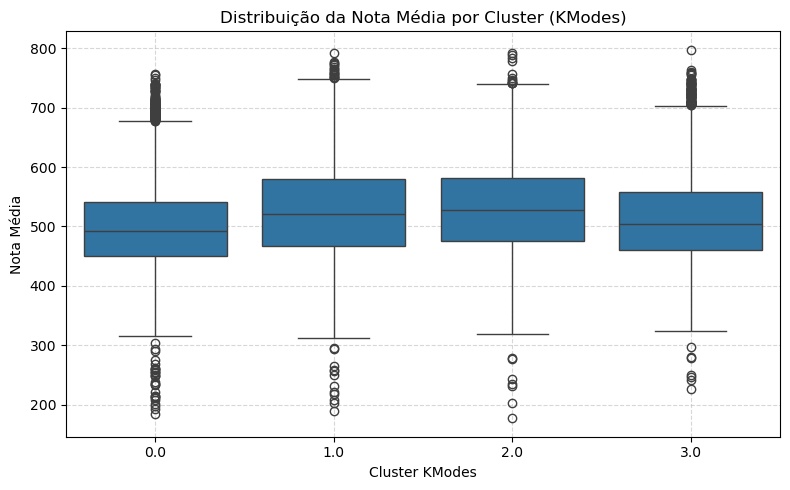

In [24]:

colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]


df_kmodes_notas = df_ifnmg[
    ["Cluster_KModes"] + colunas_notas
].dropna()

medias_notas = (
    df_kmodes_notas
    .groupby("Cluster_KModes")[colunas_notas]
    .mean()
    .round(2)
)

print("\nMédias das notas por cluster (KModes):")
print(medias_notas)

df_kmodes_notas = df_kmodes_notas.copy()
df_kmodes_notas["NOTA_MEDIA"] = df_kmodes_notas[colunas_notas].mean(axis=1)

nota_media_cluster = (
    df_kmodes_notas
    .groupby("Cluster_KModes")["NOTA_MEDIA"]
    .mean()
    .round(2)
)

print("\nNota média geral por cluster (KModes):")
print(nota_media_cluster)

descricao = (
    df_kmodes_notas
    .groupby("Cluster_KModes")[colunas_notas]
    .describe()
)

print("\nEstatísticas descritivas das notas por cluster:")
print(descricao)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_kmodes_notas,
    x="Cluster_KModes",
    y="NOTA_MEDIA"
)
plt.title("Distribuição da Nota Média por Cluster (KModes)")
plt.xlabel("Cluster KModes")
plt.ylabel("Nota Média")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

A Figura X apresenta a distribuição da nota média por cluster obtido a partir do algoritmo K-Modes. Observa-se que os clusters apresentam diferenças relevantes tanto na mediana quanto na dispersão das notas, apesar de as variáveis de desempenho não terem sido utilizadas na formação dos grupos. O Cluster 1 apresenta a maior mediana de nota média, caracterizando um perfil de melhor desempenho acadêmico, enquanto o Cluster 0 concentra as menores medianas. Os Clusters 2 e 3 apresentam perfis intermediários, sendo o Cluster 2 marcado por maior heterogeneidade interna. Esses resultados indicam associação entre características sociodemográficas e educacionais e o desempenho dos participantes.